In [2]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.io import fits

In [3]:
# Check interpretation of the power law
C = 1.089
AA = 3.4133/20.784143213520256
pdim = 1 # dimensionality of the PSD function
freqRegions = np.array((0.02,0.25,6,700,50000))
Nregions = len(freqRegions)-1
sigmaspec = np.empty((Nregions))
sigma_paper = np.array((3.2999,3.3208,3.4133,2.624))
for i in range(Nregions):
    a=freqRegions[i]
    b=freqRegions[i+1]
    sigmaspec[i] = ( (2*np.pi*AA)/(pdim-C) ) * (b**(pdim-C) - a**(pdim-C))
    print('Region ',i,':  sigma = ',sigmaspec[i], '... Paper has ',sigma_paper[i])
print('Region 0-3 RSS = ', np.sqrt(np.sum(sigmaspec**2)),'... RSS of paper values = ', np.sqrt(np.sum(sigma_paper**2)))

Region  0 :  sigma =  3.3061208311424304 ... Paper has  3.2999
Region  1 :  sigma =  3.231425270860738 ... Paper has  3.3208
Region  2 :  sigma =  3.4133 ... Paper has  3.4133
Region  3 :  sigma =  2.045574448313313 ... Paper has  2.624
Region 0-3 RSS =  6.099798024923746 ... RSS of paper values =  6.360270870018038


In [4]:
# For the present problem, I am most interested in Region 2, and 195 Å scattering, so
# I'll give explicit names to the relevant quantities:
fa = freqRegions[2]      # Lower end of frequency range (1/mm)
fb = freqRegions[3]    # Upper end of frequency range (1/mm)
sigma_ab_SunCET = sigmaspec[2]
# Just to confirm:
print('Roughness over ',fa,'/mm < f < ',fb,'/mm is ',sigma_ab_SunCET,' Å.')
sigma_ref_185_SunCET = 6.747 # Reference roughness for 185 Å (Å)
eta_185_SunCET = 0.1721/8. # Total integrated scatter for 185, per Martinez-Galarce et al.
eta_ab_SunCET = (sigma_ab_SunCET / sigma_ref_185_SunCET) * eta_185_SunCET
print('Scatter attributed to this interval: ', eta_ab_SunCET)

Roughness over  6.0 /mm < f <  700.0 /mm is  3.4133  Å.
Scatter attributed to this interval:  0.01088315047428487


In [5]:
cdelt = 4.8
rsun = 960
Nx = 2000
Ny = 1500
xmin = -(cdelt * Nx/2) / rsun
xmax = (cdelt * Nx/2) / rsun
ymin = -(cdelt * Ny/2) / rsun
ymax = (cdelt * Ny/2) / rsun
xarr = np.linspace(xmin, xmax, Nx)
yarr = np.linspace(ymin, ymax, Ny)
xarr, yarr = np.meshgrid(xarr,yarr, indexing='xy')
rarr = np.sqrt(xarr**2 + yarr**2)

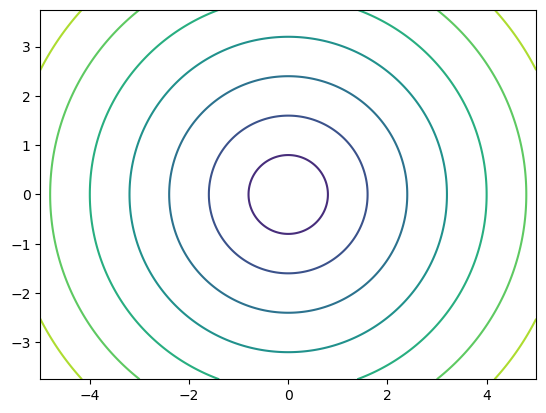

In [6]:
plt.contour(xarr, yarr, rarr)

Roughness over  6.0 /mm < f <  700.0 /mm is  3.4133  Å.
Scatter attributed to this interval:  0.01088315047428487


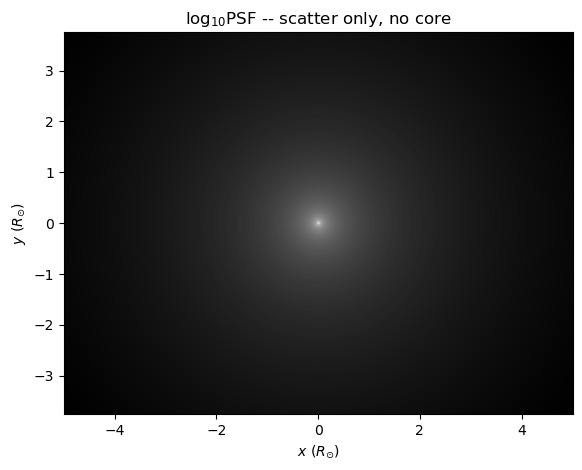

In [7]:
# Scattering model, same units as Martínez-Galarce et al.
wav_SunCET = 185        # SunCET wavelength (Å). Parameters below are for this wavelength.
RMS_ref_SunCET = 6.747  # SunCET spec RMS roughness (Å) for sigma < wavelength.
eta_SunCET = 0.1721/8.     # Total integrated scatter (TIS) for given wavelength.
wav_SunCET_mm = wav_SunCET / 1e7 # Wavelength in mm, to make proper spatial frequencies.
# Note fa, fb, sigma_ab_SUVI, eta_ab_SUVI are inherited from the mirror model above.
print('Roughness over ',fa,'/mm < f < ',fb,'/mm is ',sigma_ab_SunCET,' Å.')
print('Scatter attributed to this interval: ', eta_ab_SunCET)


theta = rarr * 960 * (1/3600) * np.pi/180 # scattering angles in radians, 
    # on same coord system as our solar image.
    # 1000 arcsec/Rsun, 1 deg/3600 arcsec, π rad / 180 deg.
frequencies = theta / wav_SunCET_mm
    # mirror spatial frequencies associated with all scattering angles (1/mm)

# We discovered that the PSF is proportional to the 1D PSD, evaluated at the appropriate frequency.
PSF = np.zeros(rarr.shape)
PSF[frequencies > 0.02] = (frequencies[frequencies > 0.02])**(-C)

normalization = eta_ab_SunCET/np.sum(PSF[(frequencies>fa) & (frequencies<fb)])
PSF *= normalization
plt.figure()
plt.imshow(np.log10(PSF), origin='lower', cmap='gray',
           extent=(xmin,xmax,ymin,ymax))
plt.title('$\log_{10}$PSF -- scatter only, no core')
plt.xlabel(r'$x\ (R_{\odot})$')
plt.ylabel(r'$y\ (R_{\odot})$')

plt.tight_layout()
plt.show()

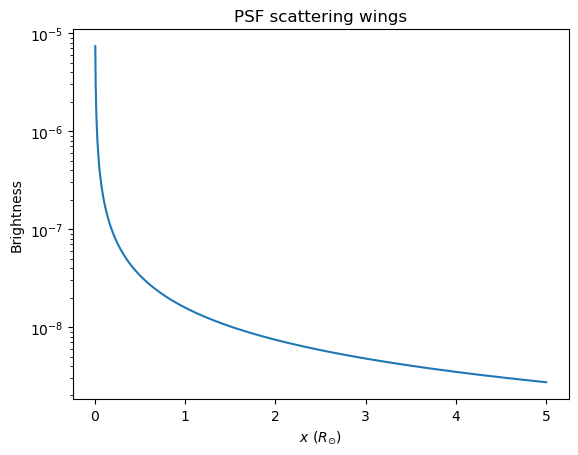

In [15]:
r1d = rarr[Ny // 2, Nx // 2:]
PSF1d = PSF[Ny // 2, Nx // 2:]

plt.figure()
plt.semilogy(r1d, PSF1d)
plt.title('PSF scattering wings')
plt.xlabel(r'$x\ (R_{\odot})$')
plt.ylabel(r'Brightness')
plt.show()

In [9]:
np.where(PSF == np.max(PSF))

(array([750]), array([1000]))

In [10]:
def make_header_template():
    from astropy.io import fits
    hdr = fits.Header( {
        "SIMPLE": "T",                   
        "BITPIX": -32,
        "NAXIS": 2,
        "NAXIS1": 2000,
        "NAXIS2": 1500,
        'WAVELNTH': 185.0, # NOTE: FITS doesn't have a keyword to store the units for wavelength, it's usually listed in the header comment instead
        'WAVEUNIT': 'Angstrom',
        'TELESCOP': 'SunCET',
        'INSTRUME': 'SunCET',
    } )
    return hdr

In [11]:
header = make_header_template()
hdu = fits.PrimaryHDU(PSF, header)
hdul = fits.HDUList(hdu)
hdul.writeto('suncet_mirror_scatter_psf_baffled.fits', overwrite=True) 

In [12]:
pwd()

'/Users/dbseaton/Documents/Ongoing_Research/SunCET/Software/suncet_instrument_simulator/suncet_instrument_simulator/Scattered Light'